In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Image Compression using SVD

Loaded sample image from sklearn
Original Matrix A (2x3):
[[1. 2. 3.]
 [4. 5. 6.]]

Matrix U ((2, 2)):
[[-0.3863177  -0.92236578]
 [-0.92236578  0.3863177 ]]

Singular Values Σ (vector): [9.508032   0.77286964]
Σ as diagonal matrix:
[[9.508032   0.        ]
 [0.         0.77286964]]

Matrix V^T ((2, 3)):
[[-0.42866713 -0.56630692 -0.7039467 ]
 [ 0.80596391  0.11238241 -0.58119908]]

Reconstructed Matrix:
[[1. 2. 3.]
 [4. 5. 6.]]

Reconstruction Error (Frobenius norm): 2.75e-15
Verification: A = UΣV^T? True
Image shape: (427, 640)
Image rank: 427


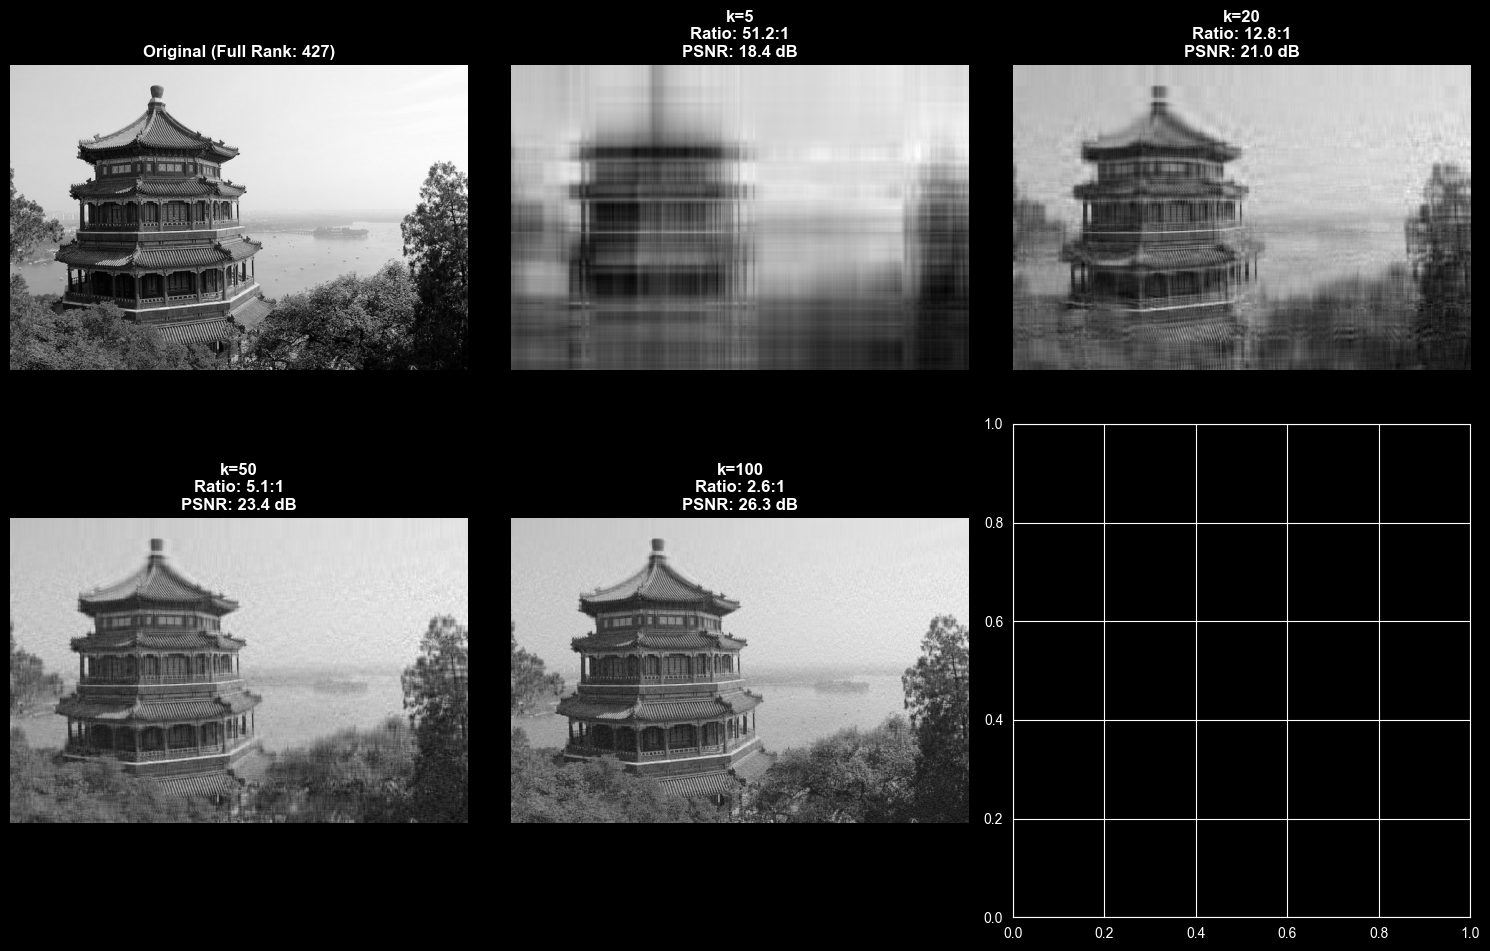


Compression Results:
k     Ratio      MSE          PSNR (dB) 
----------------------------------------
5     51.2       944.37       18.4      
20    12.8       517.96       21.0      
50    5.1        294.32       23.4      
100   2.6        150.69       26.3      


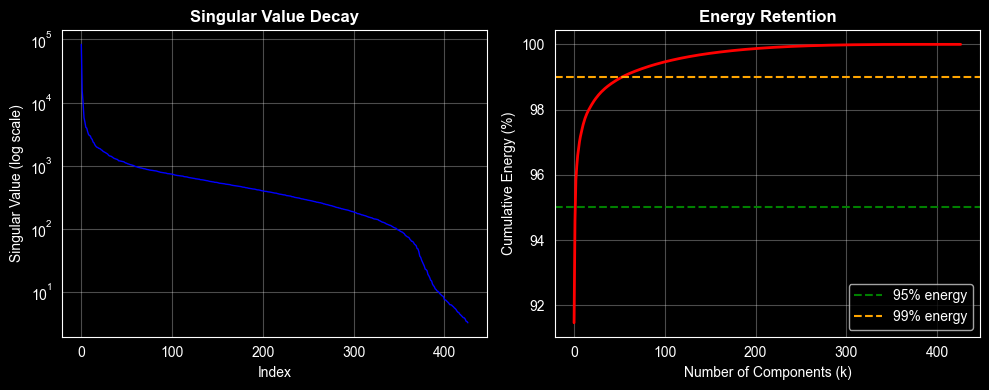


Components needed for 95% energy: 3
Components needed for 99% energy: 54


In [2]:
# Create a synthetic image (Lena-like pattern) since we can't load external images easily
def create_sample_image(size=256):
    """Create a sample grayscale image with patterns"""
    x = np.linspace(-3, 3, size)
    y = np.linspace(-3, 3, size)
    X, Y = np.meshgrid(x, y)

    # Create a pattern combining different frequencies
    Z = np.sin(X) * np.cos(Y) + 0.5 * np.sin(2*X) * np.cos(2*Y)
    Z += 0.3 * np.exp(-(X**2 + Y**2)/2)
    Z = (Z - Z.min()) / (Z.max() - Z.min()) * 255
    return Z.astype(np.uint8)

# Load or create image
try:
    # Try to load a standard test image from sklearn
    from sklearn.datasets import load_sample_image
    china = load_sample_image("china.jpg")
    image_gray = np.mean(china, axis=2).astype(np.uint8)
    print("Loaded sample image from sklearn")
except:
    image_gray = create_sample_image(256)
    print("Created synthetic test image")

import sys
import os
# Add current directory to sys.path to import from utils
sys.path.append(os.getcwd())
from utils import low_rank_approx

print(f"Image shape: {image_gray.shape}")
print(f"Image rank: {np.linalg.matrix_rank(image_gray)}")

# Perform SVD on image
U_img, s_img, Vt_img = np.linalg.svd(image_gray.astype(float), full_matrices=False)

# Compression with different k values
k_values = [5, 20, 50, 100]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original image
ax = axes[0, 0]
ax.imshow(image_gray, cmap='gray')
ax.set_title(f'Original (Full Rank: {np.linalg.matrix_rank(image_gray)})', fontweight='bold')
ax.axis('off')

# Calculate storage requirements
original_size = image_gray.shape[0] * image_gray.shape[1]

compression_results = []

for idx, k in enumerate(k_values):
    # Reconstruct with k components
    compressed_image = low_rank_approx(U_img, s_img, Vt_img, k)

    # Calculate compression ratio
    compressed_size = k * (U_img.shape[0] + 1 + Vt_img.shape[1])
    ratio = original_size / compressed_size

    # Calculate error
    mse = np.mean((image_gray - compressed_image)**2)
    psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')

    compression_results.append((k, ratio, mse, psnr))

    row = (idx + 1) // 3
    col = (idx + 1) % 3
    ax = axes[row, col]
    ax.imshow(compressed_image, cmap='gray')
    ax.set_title(f'k={k}\nRatio: {ratio:.1f}:1\nPSNR: {psnr:.1f} dB', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nCompression Results:")
print(f"{'k':<5} {'Ratio':<10} {'MSE':<12} {'PSNR (dB)':<10}")
print("-" * 40)
for k, ratio, mse, psnr in compression_results:
    print(f"{k:<5} {ratio:<10.1f} {mse:<12.2f} {psnr:<10.1f}")

# Plot singular value decay
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.semilogy(s_img, 'b-', linewidth=1)
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Value Decay', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_energy = np.cumsum(s_img**2) / np.sum(s_img**2) * 100
plt.plot(cumulative_energy, 'r-', linewidth=2)
plt.axhline(y=95, color='g', linestyle='--', label='95% energy')
plt.axhline(y=99, color='orange', linestyle='--', label='99% energy')
plt.xlabel('Number of Components (k)')
plt.ylabel('Cumulative Energy (%)')
plt.title('Energy Retention', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find k for 95% and 99% energy
k_95 = np.argmax(cumulative_energy >= 95) + 1
k_99 = np.argmax(cumulative_energy >= 99) + 1
print(f"\nComponents needed for 95% energy: {k_95}")
print(f"Components needed for 99% energy: {k_99}")